In [1]:
# %% [markdown]
# # 3. Analítica (Capa Oro)
# Inicialización de Spark para métricas de negocio.

# %%
from pyspark.sql import SparkSession
from delta import *
from pyspark.sql.functions import col

# Configuración Spark + Delta Lake
builder = SparkSession.builder \
    .appName("Lab_SECOP_Gold") \
    .master("spark://spark-master:7077") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.0.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

spark = configure_spark_with_delta_pip(builder).getOrCreate()

# %%
# Lectura de datos saneados desde la capa Silver

print("Leyendo datos desde la capa Silver...")

df_silver = (
    spark.read
    .format("delta")
    .load("/app/data/lakehouse/silver/secop")
)

print(f"Registros en Silver: {df_silver.count()}")
df_silver.printSchema()



:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-08522427-7e72-420a-b652-6a0560fb5303;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 147ms :: artifacts dl 6ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   

Leyendo datos desde la capa Silver...


26/02/02 01:04:31 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Registros en Silver: 7942
root
 |-- id_contrato: string (nullable = true)
 |-- referencia_del_contrato: string (nullable = true)
 |-- estado_contrato: string (nullable = true)
 |-- nombre_entidad: string (nullable = true)
 |-- nit_entidad: string (nullable = true)
 |-- departamento: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- sector: string (nullable = true)
 |-- rama: string (nullable = true)
 |-- entidad_centralizada: string (nullable = true)
 |-- tipo_de_contrato: string (nullable = true)
 |-- modalidad_de_contratacion: string (nullable = true)
 |-- codigo_de_categoria_principal: string (nullable = true)
 |-- descripcion_del_proceso: string (nullable = true)
 |-- objeto_del_contrato: string (nullable = true)
 |-- fecha_de_inicio_del_contrato: date (nullable = true)
 |-- fecha_de_fin_del_contrato: date (nullable = true)
 |-- valor_del_contrato: double (nullable = true)
 |-- valor_pagado: double (nullable = true)
 |-- valor_facturado: double (nullable = true)
 

26/02/02 01:04:45 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [11]:
from pyspark.sql.functions import sum, count, desc, col

df_gold = (
    df_silver
    .withColumn("valor_del_contrato_num", col("valor_del_contrato").cast("double"))
    .groupBy("departamento")
    .agg(
        sum("valor_del_contrato_num").alias("total_inversion"),
        count("id_contrato").alias("cantidad_contratos")
    )
    .orderBy(desc("total_inversion"))
    .limit(10)
)

print("Top 10 Departamentos por inversión:")
df_gold.show(truncate=False)



Top 10 Departamentos por inversión:
+--------------------------+------------------+------------------+
|departamento              |total_inversion   |cantidad_contratos|
+--------------------------+------------------+------------------+
|Distrito Capital de Bogotá|2.7017612050193E13|4890              |
|Caquetá                   |7.336059970671E12 |46                |
|No Definido               |5.46082744506E11  |1218              |
|Atlántico                 |2.23835941912E11  |62                |
|Antioquia                 |1.32544390758E11  |238               |
|Cundinamarca              |1.14870732574E11  |170               |
|Tolima                    |2.723840994E10    |302               |
|Bolívar                   |2.6159602529E10   |111               |
|Caldas                    |1.1377888028E10   |38                |
|La Guajira                |8.727721698E9     |50                |
+--------------------------+------------------+------------------+



In [4]:
%pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 14.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 10.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 13.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 14.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 4.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


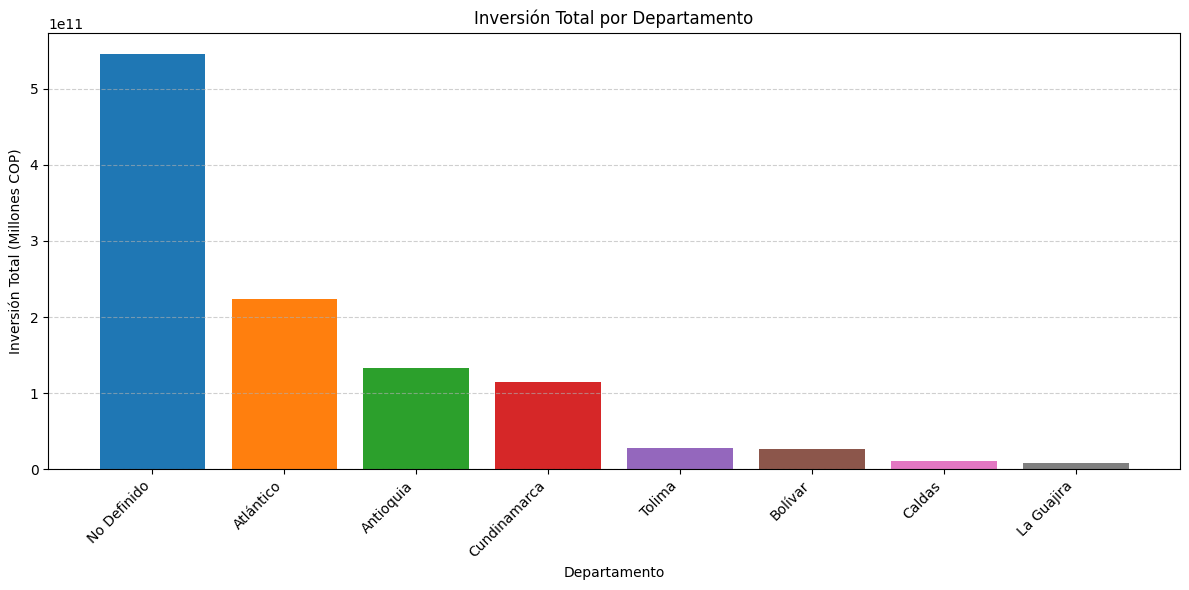

In [12]:
import matplotlib.pyplot as plt

# Convertir a Pandas
pdf_gold = df_gold.toPandas()

# Excluir los dos primeros (outliers)
pdf_gold_plot = pdf_gold.iloc[2:]

plt.figure(figsize=(12, 6))

plt.bar(
    pdf_gold_plot["departamento"],
    pdf_gold_plot["total_inversion"],
    color=plt.cm.tab10.colors
)

plt.title("Inversión Total por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Inversión Total (Millones COP)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [13]:
# %%
# Persistir Capa Oro (Delta Lake)
gold_path = "/app/data/lakehouse/gold/top_deptos"

(
    df_gold
    .write
    .format("delta")
    .mode("append")
    .save(gold_path)
)

print("Datos escritos en la capa Gold")
print(f"Ruta: {gold_path}")


[Stage 57:========================================>               (36 + 2) / 50]

Datos escritos en la capa Gold
Ruta: /app/data/lakehouse/gold/top_deptos


In [14]:
spark.sql("""
DESCRIBE HISTORY delta.`/app/data/lakehouse/gold/top_deptos`
""").show(truncate=False)

[Stage 61:=============================>                            (1 + 1) / 2]

+-------+-----------------------+------+--------+---------+-----------------------------------+----+--------+---------+-----------+--------------+-------------+------------------------------------------------------------+------------+-----------------------------------+
|version|timestamp              |userId|userName|operation|operationParameters                |job |notebook|clusterId|readVersion|isolationLevel|isBlindAppend|operationMetrics                                            |userMetadata|engineInfo                         |
+-------+-----------------------+------+--------+---------+-----------------------------------+----+--------+---------+-----------+--------------+-------------+------------------------------------------------------------+------------+-----------------------------------+
|0      |2026-02-02 01:50:00.893|NULL  |NULL    |WRITE    |{mode -> Append, partitionBy -> []}|NULL|NULL    |NULL     |NULL       |Serializable  |true         |{numFiles -> 1, numOutputRo

In [15]:
spark.stop()